<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



 # <span style="color:brown;">**Descomposición Canónica**</span>




 <span style="color:blue;">**Alumna: Florencio Florecio Miriam Lizeth**</span>



**Objetivo**: Poder comprender que  la descomposición canónica sirve para simplificar, entender, predecir y calcular de manera más eficiente el comportamiento de sistemas matemáticos.
en un sentido más conceptual, el objetivo es ver la “esencia” del sistema: separar lo importante de lo accesorio. Dos matrices distintas pueden tener la misma forma canónica, lo que significa que, en el fondo, representan el mismo tipo de comportamiento.



 <span style="color:green;">**1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.**</span>




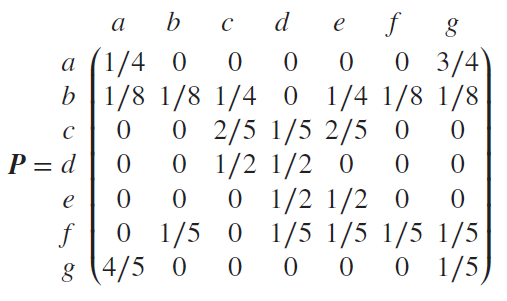

In [47]:
#Realizamosla importacion de librerias
import numpy as np
from sympy import Matrix , init_printing
import sympy as sp
import networkx as nx
import matplotlib.cm
import matplotlib.pyplot as plt

In [48]:
import sympy as sp

P = sp.Matrix([
    [sp.Rational(1,4), 0,   0,   0,   0,   0,   sp.Rational(3,4)],
    [sp.Rational(1,8), sp.Rational(1,8), sp.Rational(1,4), 0,   sp.Rational(1,4), sp.Rational(1,8), sp.Rational(1,8)],
    [0,   0,   sp.Rational(2,5), sp.Rational(1,5), sp.Rational(2,5), 0,   0],
    [0,   0,   sp.Rational(1,2), sp.Rational(1,2), 0,   0,   0],
    [0,   0,   0,   sp.Rational(1,2), sp.Rational(1,2), 0,   0],
    [0,   sp.Rational(1,5), 0,   sp.Rational(1,5), sp.Rational(1,5), sp.Rational(1,5), sp.Rational(1,5)],
    [sp.Rational(4,5), 0,   0,   0,   0,   0,   sp.Rational(1,5)]
])

print("Matriz de Transición de P:")
print("\n")
P

Matriz de Transición de P:




Matrix([
[1/4,   0,   0,   0,   0,   0, 3/4],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
[4/5,   0,   0,   0,   0,   0, 1/5]])

Procedemos a crear los nodos y las flechas parapoder realizar el *Diagrama de Transicion* para la matriz P, con la ayuda de las librerias numpy, matplotlib.pyplot y networkx

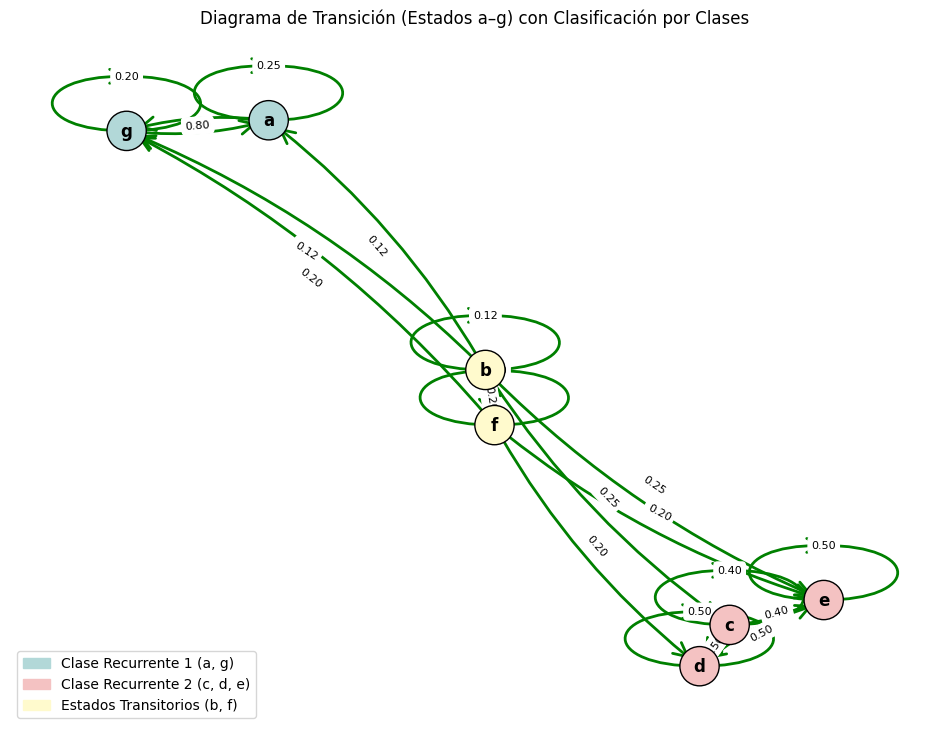

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm
import matplotlib.patches as mpatches

# Crear grafo dirigido
G = nx.DiGraph()

# Estados (a–g)
labels = ['a','b','c','d','e','f','g']
n = len(labels)

# Asumiendo que P (matriz de sympy) está definida en una celda precedente
P_np = np.array(P.tolist(), dtype=float)

# Añadir nodos
for i in range(n):
    G.add_node(i)

# Añadir aristas automáticamente según la matriz P
for i in range(n):
    for j in range(n):
        if P_np[i, j] > 0: # Usar P_np para comparación numérica
            G.add_edge(i, j, label=P_np[i, j]) # Usar P_np para la etiqueta

# Usar un algoritmo de layout para calcular las posiciones de los nodos
# nx.spring_layout() es una buena opción para un layout general.
pos = nx.spring_layout(G)

# --- Calcular estados recurrentes y transitorios y sus clases ---
sccs = list(nx.strongly_connected_components(G))

recurrent_classes_sccs = [] # Para almacenar los SCCs recurrentes
transient_states_set = set() # Para almacenar todos los estados transitorios

for scc in sccs:
    is_recurrent_class = True
    for u in scc:
        for v in G.successors(u):
            if v not in scc:
                is_recurrent_class = False
                break
        if not is_recurrent_class:
            break

    if is_recurrent_class:
        recurrent_classes_sccs.append(scc)
    else:
        # Los estados en SCCs no recurrentes son transitorios
        transient_states_set.update(scc)

# Cualquier estado que no esté en una clase recurrente es transitorio
all_states = set(range(n))
all_recurrent_states_flat = set().union(*recurrent_classes_sccs)
transient_states_set = all_states - all_recurrent_states_flat
# --- Fin del cálculo de estados y clases ---

plt.figure(figsize=(12,9))

# --- Definir colores pastel ---
pastel_colors = [
    '#B2D8D8', # Verde menta pastel
    '#F4C2C2', # Rosa pastel
    '#C3B1E1', # Lavanda pastel
    '#ACE1AF', # Verde claro pastel
    '#FFDDC1', # Melocotón pastel
    '#DAF7A6', # Verde limón pastel
    '#FFC0CB'  # Rosa cereza pastel
]
transient_color = '#FFFACD' # Amarillo pálido para estados transitorios

node_colors_map = [None] * n # Inicializar el mapa de colores de nodos

# Asignar colores a las clases recurrentes
for k, scc_class in enumerate(recurrent_classes_sccs):
    color = pastel_colors[k % len(pastel_colors)] # Ciclar a través de los colores
    for state_idx in scc_class:
        node_colors_map[state_idx] = color

# Asignar color a los estados transitorios
for state_idx in transient_states_set:
    node_colors_map[state_idx] = transient_color

# Asegurarse de que todos los estados tengan un color (esto debería cubrir todos los casos)
for i in range(n):
    if node_colors_map[i] is None:
        node_colors_map[i] = 'gray' # Color por defecto si algo se pasa

# Dibujar nodos
nx.draw_networkx_nodes(G, pos,
    node_color=node_colors_map, # Usar los colores generados basado en la clasificación
    node_size=800,
    edgecolors='black'
)

# Dibujar aristas
nx.draw_networkx_edges(G, pos,
    arrows=True,
    arrowstyle='->',
    arrowsize=25, # Tamaño de flecha aumentado
    width=2,      # Ancho de las flechas añadido
    edge_color='green', # Flechas verdes
    connectionstyle='arc3,rad=0.1'
)

# Etiquetas de nodos
nx.draw_networkx_labels(G, pos,
    labels={i: labels[i] for i in range(n)},
    font_size=12,
    font_weight='bold'
)

# Etiquetas de probabilidades
edge_labels = {(u, v): f'{d["label"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Diagrama de Transición (Estados a–g) con Clasificación por Clases")
plt.axis('off')

# --- Adición: Leyenda para los colores ---
legend_handles = []

# Añadir leyendas para las clases recurrentes
for k, scc_class in enumerate(recurrent_classes_sccs):
    states_str = ', '.join([labels[s] for s in sorted(list(scc_class))])
    color = pastel_colors[k % len(pastel_colors)]
    legend_handles.append(mpatches.Patch(color=color, label=f'Clase Recurrente {k+1} ({states_str})'))

# Añadir leyenda para los estados transitorios
states_str_transient = ', '.join([labels[s] for s in sorted(list(transient_states_set))])
legend_handles.append(mpatches.Patch(color=transient_color, label=f'Estados Transitorios ({states_str_transient})'))

plt.legend(handles=legend_handles, loc='lower left')

plt.show()

Como podemos observar en el diagrama tenemos estados recurrentes y estados transitorios, los cuales los estados recurrentes son aquellos siempre van a regresar con probabilidad 1, mientras que en los estados transtorios es aquel al que puedes dejar de visitar para siempre.

In [50]:
# Encontrar las componentes fuertemente conectadas (SCCs)
sccs = list(nx.strongly_connected_components(G))

print(f"Componentes Fuertemente Conectadas (SCCs): {sccs}")

# Identificar estados recurrentes y transitorios
recurrent_states = set()
transient_states = set()

# Convertir las etiquetas a un diccionario para una fácil referencia
label_to_index = {label: i for i, label in enumerate(labels)}

for scc in sccs:
    is_recurrent_class = True
    for u in scc:
        for v in G.successors(u):
            if v not in scc:
                is_recurrent_class = False
                break
        if not is_recurrent_class:
            break

    if is_recurrent_class:
        recurrent_states.update(scc)
    else:
        transient_states.update(scc)

# Cualquier estado que no esté en una SCC que sea clase recurrente, y tampoco sea parte de una SCC que se identifique como transitoria
# (porque puede ser una SCC que tiene salidas a otras SCCs), debe ser analizado.
# Una forma más sencilla es que los estados no recurrentes son transitorios.
all_states = set(range(n))
transient_states = all_states - recurrent_states

print("\nEstados Recurrentes:")
for s_idx in sorted(list(recurrent_states)):
    print(f"- {labels[s_idx]}")

print("\nEstados Transitorios:")
for s_idx in sorted(list(transient_states)):
    print(f"- {labels[s_idx]}")


Componentes Fuertemente Conectadas (SCCs): [{0, 6}, {2, 3, 4}, {1, 5}]

Estados Recurrentes:
- a
- c
- d
- e
- g

Estados Transitorios:
- b
- f


Con esto confirmamos que los estados  son los siguientes:




*    **Clase {b,f} ← Estados Transitorios**


*  **Clase {a,g} ← Estados Recurrentes**
*   **Clase {c,d,e} ← Estados Recurrentes**



 <span style="color:green;">**2.Determine si la matriz tiene o no distribución límite.**</span>



In [51]:
# 1. Verificar irreducibilidad

P_np = np.array(P.tolist(), dtype=float) # Convertir la matriz de SymPy P a un array de NumPy P_np
G = nx.DiGraph(P_np)

if nx.is_strongly_connected(G):
    print("La cadena es IRREDUCIBLE")
else:
    print("La cadena NO es irreducible")

La cadena NO es irreducible


In [52]:

# 2. Verificar periodicidad

periodos = []

for i in range(len(P_np)):
    ciclos = []
    for n_power in range(1, 20): # Cambiado 'n' a 'n_power' para evitar conflicto con la variable 'n' de tamaño de estados
        if np.linalg.matrix_power(P_np, n_power)[i][i] > 0:
            ciclos.append(n_power)
    if len(ciclos) > 0:
        d = np.gcd.reduce(ciclos)
        periodos.append(d)

if all(p == 1 for p in periodos):
    print("La cadena es APERIÓDICA")
else:
    print("La cadena NO es aperiódica")


La cadena es APERIÓDICA


In [53]:

# 3. Distribución estacionaria

# Resolver πP = π  → (P^T - I)π = 0
A = P.T - sp.eye(P.shape[0])

# Agregar condición suma = 1
A = A.row_insert(P.shape[0], sp.ones(1, P.shape[0]))
b = sp.Matrix([0]*P.shape[0] + [1])

pi = A.gauss_jordan_solve(b)[0]

print("\nDistribución estacionaria:")
print("\n")
sp.pprint(pi)



Distribución estacionaria:


⎡   16⋅τ₀   ⎤
⎢   ─────   ⎥
⎢    15     ⎥
⎢           ⎥
⎢     0     ⎥
⎢           ⎥
⎢ 1   31⋅τ₀ ⎥
⎢ ─ - ───── ⎥
⎢ 3    45   ⎥
⎢           ⎥
⎢ 2   62⋅τ₀ ⎥
⎢ ─ - ───── ⎥
⎢ 5    75   ⎥
⎢           ⎥
⎢4    124⋅τ₀⎥
⎢── - ──────⎥
⎢15    225  ⎥
⎢           ⎥
⎢     0     ⎥
⎢           ⎥
⎣    τ₀     ⎦


In [54]:

# 4. Verificar convergencia

P_inf = np.linalg.matrix_power(P_np, 100)

print("\nAproximación de P^n (n grande):")
print(np.round(P_inf, 4))

# CONCLUSIÓN

if nx.is_strongly_connected(G) and all(p == 1 for p in periodos):
    print("\n✔ Existe distribución límite única")
else:
    print("\n✘ No existe distribución límite única")



Aproximación de P^n (n grande):
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]

✘ No existe distribución límite única


Una cadena de Markov solo tiene una distribución límite única si es irreducible (todos los estados se comunican entre sí) y aperiódica (no vuelve a sí misma en un patrón regular fijo). Como se determinó previamente, nuestra cadena NO es irreducible (tiene clases recurrentes separadas y estados transitorios).

In [55]:
# Calcular la matriz fundamental N = (I - Q)^-1
k = len(transient_indices) # Asegurar que k tenga el valor correcto
I_k = sp.eye(k) # Matriz identidad de tamaño k x k
N = (I_k - Q).inv()

print("Matriz Fundamental N:")
sp.pprint(N)

# Calcular las probabilidades de absorción F = N * S
F = N * S

print("\nMatriz de Probabilidades de Absorción F:")
sp.pprint(F)

print("\nInterpretación de F:")
for i, t_idx in enumerate(transient_indices):
    print(f"Desde el estado transitorio {labels[t_idx]} ({t_idx}):")
    for j, r_idx in enumerate(recurrent_indices):
        print(f"  - Probabilidad de ser absorbido en {labels[r_idx]} ({r_idx}): {F[i, j]:.4f}")

Matriz Fundamental N:
⎡ 32       ⎤
⎢ ──   5/27⎥
⎢ 27       ⎥
⎢          ⎥
⎢       35 ⎥
⎢8/27   ── ⎥
⎣       27 ⎦

Matriz de Probabilidades de Absorción F:
⎡0.148148148148148  0.296296296296296   0.037037037037037  0.333333333333333   ↪
⎢                                                                              ↪
⎣0.037037037037037  0.0740740740740741  0.259259259259259  0.333333333333333   ↪

↪ 0.185185185185185⎤
↪                  ⎥
↪ 0.296296296296296⎦

Interpretación de F:
Desde el estado transitorio b (1):
  - Probabilidad de ser absorbido en a (0): 0.1481
  - Probabilidad de ser absorbido en c (2): 0.2963
  - Probabilidad de ser absorbido en d (3): 0.0370
  - Probabilidad de ser absorbido en e (4): 0.3333
  - Probabilidad de ser absorbido en g (6): 0.1852
Desde el estado transitorio f (5):
  - Probabilidad de ser absorbido en a (0): 0.0370
  - Probabilidad de ser absorbido en c (2): 0.0741
  - Probabilidad de ser absorbido en d (3): 0.2593
  - Probabilidad de ser absorbido en e

Estos resultados nos dan una comprensión profunda de cómo los estados transitorios eventualmente conducen a la absorción en los diferentes estados recurrentes, cuantificando esas probabilidades




 <span style="color:green;">**3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.**</span>

En este caso, la matriz `P` se ha reordenado para revelar su **estructura canónica**, que es como desglosar el mapa de nuestras transiciones en secciones con un propósito claro:

$ <br>
\begin{pmatrix}
\begin{array}{cc|cc|ccc}
\frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{4} & 0 & \frac{1}{4} \\
\frac{1}{5} & \frac{1}{5} & \frac{1}{5} & 0 & 0 & \frac{1}{5} & \frac{1}{5} \\
\hline
0 & 0 & \frac{1}{5} & \frac{4}{5} & 0 & 0 & 0 \\
0 & 0 & \frac{3}{4} & \frac{1}{4} & 0 & 0 & 0 \\
\hline
0 & 0 & 0 & 0 & \frac{2}{5} & \frac{1}{5} & \frac{2}{5} \\
0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2}
\end{array}
\end{pmatrix}
 $

Donde:

*   **Q (2×2): El Bloque de los "Visitantes Temporales"**
    Este bloque, en la esquina superior izquierda, describe cómo los **estados transitorios {b, f}** interactúan entre sí. Son como turistas en una ciudad: pueden moverse entre ellos, pero eventualmente saldrán para no volver a la zona transitoria.

*   **R₁ (2×2): El Puente a la Clase Recurrente {g,a}**
    Este bloque representa las transiciones directas de los estados transitorios {b, f} hacia la **primera clase recurrente {g, a}**. Es el "puente" que los lleva de un área temporal a una permanente.

*   **R₂ (2×3): El Puente a la Clase Recurrente {c,d,e}**
    Similar a R₁, este bloque muestra cómo los estados transitorios {b, f} pueden pasar a la **segunda clase recurrente {c, d, e}**. Es otro "puente" hacia un destino final.

*   **P₁ (2×2): La "Vida" en la Clase Recurrente {g,a}**
    Ubicado en el centro, este bloque describe las transiciones *dentro* de la **primera clase recurrente {g, a}**. Una vez que la cadena entra aquí, se queda girando en estos estados; nunca los abandona para ir a un estado transitorio.

*   **P₂ (3×3): La "Vida" en la Clase Recurrente {c,d,e}**
    Este bloque, en la esquina inferior derecha, funciona igual que P₁. Muestra las transiciones *dentro* de la **segunda clase recurrente {c, d, e}**. Aquí también, una vez que la cadena llega, permanece indefinidamente dentro de esta clase.

*   **Bloques de Ceros: Las "Salidas Cerradas"**
    Los bloques de ceros indican que **no hay transiciones posibles de los estados recurrentes de vuelta a los transitorios**. Es decir, una vez que la cadena entra en una clase recurrente (P₁ o P₂), no hay camino de regreso a los estados transitorios (Q). Son como puertas de entrada unidireccionales a las zonas permanentes.

In [56]:
# Nuevo orden dada las clases: {b,f} transitoria, {g,a} recurrente, {c,d,e} recurrente
nuevo_orden = ['b', 'f', 'g', 'a', 'c', 'd', 'e']
indices_nuevo = [labels.index(e) for e in nuevo_orden]

In [81]:
P_canonica = P.extract(indices_nuevo, indices_nuevo)

print("Estados reordenados:", nuevo_orden)
print("\nMatriz en forma canónica:")
# Imprimir la matriz SymPy directamente para mantener las fracciones
print("         ", " ".join(f'{s: <7}' for s in nuevo_orden))
for i, estado in enumerate(nuevo_orden):
    # Convertir cada elemento de la fila de la matriz SymPy a string para formatear
    row_str = [str(elem) for elem in P_canonica.row(i)]
    print(f"{estado: <8}" + " ".join(f'{x: <7}' for x in row_str))

Estados reordenados: ['b', 'f', 'g', 'a', 'c', 'd', 'e']

Matriz en forma canónica:
          b       f       g       a       c       d       e      
b       1/8     1/8     1/8     1/8     1/4     0       1/4    
f       1/5     1/5     1/5     0       0       1/5     1/5    
g       0       0       1/5     4/5     0       0       0      
a       0       0       3/4     1/4     0       0       0      
c       0       0       0       0       2/5     1/5     2/5    
d       0       0       0       0       1/2     1/2     0      
e       0       0       0       0       0       1/2     1/2    


In [58]:
# Extraer submatrices
# Q: transiciones entre transitorios {b,f} → {b,f}
Q = P_canonica[0:2, 0:2]
print("Submatriz Q (transitorio → transitorio):")
Q

Submatriz Q (transitorio → transitorio):


Matrix([
[1/8, 1/8],
[1/5, 1/5]])

In [59]:
# R1: transiciones de transitorios a recurrentes {g,a}
R1 = P_canonica[0:2, 2:4]
print("\nSubmatriz R1 (transitorio → recurrente {g,a}):")
R1


Submatriz R1 (transitorio → recurrente {g,a}):


Matrix([
[1/8, 1/8],
[1/5,   0]])

In [60]:
# R2: transiciones de transitorios a recurrentes {c,d,e}
R2 = P_canonica[0:2, 4:7]
print("\nSubmatriz R2 (transitorio → recurrente {c,d,e}):")
R2


Submatriz R2 (transitorio → recurrente {c,d,e}):


Matrix([
[1/4,   0, 1/4],
[  0, 1/5, 1/5]])

In [61]:
# R completa
R = P_canonica[0:2, 2:7]
R

Matrix([
[1/8, 1/8, 1/4,   0, 1/4],
[1/5,   0,   0, 1/5, 1/5]])

In [62]:
# P1: transiciones dentro de clase recurrente {g,a}
P1 = P_canonica[2:4, 2:4]
print("\nSubmatriz P1 (recurrente {g,a}):")
P1


Submatriz P1 (recurrente {g,a}):


Matrix([
[1/5, 4/5],
[3/4, 1/4]])

In [63]:
# P2: transiciones dentro de clase recurrente {c,d,e}
P2 = P_canonica[4:7, 4:7]
print("\nSubmatriz P2 (recurrente {c,d,e}):")
P2


Submatriz P2 (recurrente {c,d,e}):


Matrix([
[2/5, 1/5, 2/5],
[1/2, 1/2,   0],
[  0, 1/2, 1/2]])

In [83]:
# Matriz fundamental N = (I - Q)^(-1)
I2 = np.eye(2)
Q_np = np.array(Q.tolist(), dtype=float) # Convertir Q a un array de NumPy
N_np = np.linalg.inv(I2 - Q_np)

print("\nMatriz fundamental N = (I - Q)^(-1):")

print("\n")
# Convertir a SymPy Matrix para una impresión más bonita
N_sympy = sp.Matrix(N_np)
sp.pprint(N_sympy)

# Verificar: N debe tener entradas positivas
print(f"\n¿N > 0? {np.all(N_np > 0)}")


Matriz fundamental N = (I - Q)^(-1):


⎡1.18518518518519   0.185185185185185⎤
⎢                                    ⎥
⎣0.296296296296296   1.2962962962963 ⎦

¿N > 0? True


In [85]:
# Probabilidades de absorción B = N @ R
R_np = np.array(R.tolist(), dtype=float) # Convertir R a un array de NumPy
B_np = N_np @ R_np # Usar N_np en lugar de N

print("\nMatriz de absorción B = N @ R:")

print("\n")
print("Filas: b, f | Columnas: g, a, c, d, e")
print("\n")
# Convertir a SymPy Matrix
B_sympy = sp.Matrix(B_np)
sp.pprint(B_sympy)


Matriz de absorción B = N @ R:


Filas: b, f | Columnas: g, a, c, d, e


⎡0.185185185185185  0.148148148148148  0.296296296296296   0.037037037037037   ↪
⎢                                                                              ↪
⎣0.296296296296296  0.037037037037037  0.0740740740740741  0.259259259259259   ↪

↪ 0.333333333333333⎤
↪                  ⎥
↪ 0.333333333333333⎦


In [88]:
# Separar B en B1 (absorción en {g,a}) y B2 (absorción en {c,d,e})
B1 = B_np[:, 0:2]  # absorción en {g,a}. Usar B_np porque B es ahora un SymPy Matrix para pprint.
B2 = B_np[:, 2:5]  # absorción en {c,d,e}. Usar B_np porque B es ahora un SymPy Matrix para pprint.

print("\nB1 - Probabilidades de absorción en {g,a}:")
print("\n")
sp.pprint(sp.Matrix(B1))
print("\n")
print(f"  Desde b: P(g)={B1[0,0]:.4f}, P(a)={B1[0,1]:.4f}")
print(f"  Desde f: P(g)={B1[1,0]:.4f}, P(a)={B1[1,1]:.4f}")

print("\nB2 - Probabilidades de absorción en {c,d,e}:")
print("\n")
sp.pprint(sp.Matrix(B2))
print("\n")
print(f"  Desde b: P(c)={B2[0,0]:.4f}, P(d)={B2[0,1]:.4f}, P(e)={B2[0,2]:.4f}")
print(f"  Desde f: P(c)={B2[1,0]:.4f}, P(d)={B2[1,1]:.4f}, P(e)={B2[1,2]:.4f}")


B1 - Probabilidades de absorción en {g,a}:


⎡0.185185185185185  0.148148148148148⎤
⎢                                    ⎥
⎣0.296296296296296  0.037037037037037⎦


  Desde b: P(g)=0.1852, P(a)=0.1481
  Desde f: P(g)=0.2963, P(a)=0.0370

B2 - Probabilidades de absorción en {c,d,e}:


⎡0.296296296296296   0.037037037037037  0.333333333333333⎤
⎢                                                        ⎥
⎣0.0740740740740741  0.259259259259259  0.333333333333333⎦


  Desde b: P(c)=0.2963, P(d)=0.0370, P(e)=0.3333
  Desde f: P(c)=0.0741, P(d)=0.2593, P(e)=0.3333


In [90]:
# Calcular la matriz fundamental N = (I - Q)^-1
k = len(transient_indices) # Número de estados transitorios
I_k = sp.eye(k) # Matriz identidad de tamaño k x k
N = (I_k - Q).inv() # N ya es una matriz SymPy

print("Matriz Fundamental N:")
print("\n")
sp.pprint(N)

# Calcular las probabilidades de absorción F = N * R (donde R es la submatriz transitorio -> recurrente)
# R fue definida previamente como P_canonica[0:2, 2:7]
F = N * R

print("\nMatriz de Probabilidades de Absorción F:")
print("\n")
sp.pprint(F)

print("\nInterpretación de F:")
print("\n")
# Las columnas de F corresponden al orden de los estados recurrentes en la forma canónica (nuevo_orden[2:])
recurrent_states_in_F_order_labels = nuevo_orden[2:]

for i, t_idx in enumerate(transient_indices):
    print(f"Desde el estado transitorio {labels[t_idx]} ({t_idx}):")
    for j, r_label in enumerate(recurrent_states_in_F_order_labels):
        print(f"  - Probabilidad de ser absorbido en {r_label} ({labels.index(r_label)}): {F[i, j]:.4f}")

Matriz Fundamental N:


⎡ 32       ⎤
⎢ ──   5/27⎥
⎢ 27       ⎥
⎢          ⎥
⎢       35 ⎥
⎢8/27   ── ⎥
⎣       27 ⎦

Matriz de Probabilidades de Absorción F:


⎡5/27  4/27  8/27  1/27  1/3⎤
⎢                           ⎥
⎣8/27  1/27  2/27  7/27  1/3⎦

Interpretación de F:


Desde el estado transitorio b (1):
  - Probabilidad de ser absorbido en g (6): 0.1852
  - Probabilidad de ser absorbido en a (0): 0.1481
  - Probabilidad de ser absorbido en c (2): 0.2963
  - Probabilidad de ser absorbido en d (3): 0.0370
  - Probabilidad de ser absorbido en e (4): 0.3333
Desde el estado transitorio f (5):
  - Probabilidad de ser absorbido en g (6): 0.2963
  - Probabilidad de ser absorbido en a (0): 0.0370
  - Probabilidad de ser absorbido en c (2): 0.0741
  - Probabilidad de ser absorbido en d (3): 0.2593
  - Probabilidad de ser absorbido en e (4): 0.3333


In [91]:
# Verificamos que las probabilidades de absorción suman 1
print(f"\n¿Filas de B suman 1? {np.allclose(B.sum(axis=1), 1)}")


¿Filas de B suman 1? True


### Verificación de las Probabilidades de Absorción

Un aspecto crucial de las matrices de probabilidades de absorción es que la suma de las probabilidades en cada fila debe ser igual a 1. Esto significa que, una vez que la cadena entra en un estado transitorio, es **seguro** que eventualmente será absorbida por una de las clases recurrentes.

El cálculo `np.allclose(B.sum(axis=1), 1)` nos permite confirmar si esta propiedad se cumple, considerando posibles pequeñas diferencias de precisión flotante.


In [92]:
# Verificamos si la suma de las filas de la matriz B es aproximadamente igual a 1
suma_filas_B_cercana_a_uno = np.allclose(B_np.sum(axis=1), 1)

print(f"¿Las filas de la matriz de absorción (B) suman aproximadamente 1? {suma_filas_B_cercana_a_uno}")

if suma_filas_B_cercana_a_uno:
    print("\n✅ Esto confirma que desde cualquier estado transitorio, la cadena de Markov tiene una probabilidad total de 1 de ser absorbida en algún estado recurrente.")
else:
    print("\n❌ ¡Advertencia! Las sumas de las filas de B no son cercanas a 1, lo que podría indicar un error en los cálculos o en la interpretación.")


¿Las filas de la matriz de absorción (B) suman aproximadamente 1? True

✅ Esto confirma que desde cualquier estado transitorio, la cadena de Markov tiene una probabilidad total de 1 de ser absorbida en algún estado recurrente.


Calcula la distribución estacionaria de una submatriz con $π=πP$



In [73]:
def distribucion_estacionaria(P_sub):
    """Calcula la distribución estacionaria de una submatriz."""
    n = P_sub.shape[0]
    # Convertir P_sub a un array de NumPy si no lo es ya
    P_sub_np = np.array(P_sub.tolist(), dtype=float)
    # Resolver πP = π, Σπ = 1
    A = np.vstack([P_sub_np.T - np.eye(n), np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    pi, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    return pi

In [74]:
pi1 = distribucion_estacionaria(P1)
print(f"\nDistribución estacionaria de P1 ({'g,a'}):")
print(f"  π_g = {pi1[0]:.4f}, π_a = {pi1[1]:.4f}")
print(f"  Verificación: {pi1[0]:.4f} + {pi1[1]:.4f} = {pi1.sum():.4f}")


Distribución estacionaria de P1 (g,a):
  π_g = 0.4839, π_a = 0.5161
  Verificación: 0.4839 + 0.5161 = 1.0000


In [75]:
pi2 = distribucion_estacionaria(P2)
print(f"\nDistribución estacionaria de P2 ({'c,d,e'}):")
print(f"  π_c = {pi2[0]:.4f}, π_d = {pi2[1]:.4f}, π_e = {pi2[2]:.4f}")
print(f"  Verificación: {pi2[0]:.4f} + {pi2[1]:.4f} + {pi2[2]:.4f} = {pi2.sum():.4f}")


Distribución estacionaria de P2 (c,d,e):
  π_c = 0.3333, π_d = 0.4000, π_e = 0.2667
  Verificación: 0.3333 + 0.4000 + 0.2667 = 1.0000


In [96]:
# Construir la matriz límite usando la descomposición canónica
P_limite_canonica = np.zeros((7, 7))

# Bloque de transitorios: B1 * distribución estacionaria P1 y B2 * distribución estacionaria P2
P_limite_canonica[0:2, 2:4] = B1  # Desde transitorios a recurrentes {g,a}
P_limite_canonica[0:2, 4:7] = B2  # Desde transitorios a recurrentes {c,d,e}

# Bloque de recurrentes {g,a}: la distribución estacionaria π1 se repite en cada fila
for i in range(2):
    P_limite_canonica[2+i, 2:4] = pi1

# Bloque de recurrentes {c,d,e}: la distribución estacionaria π2 se repite en cada fila
for i in range(3):
    P_limite_canonica[4+i, 4:7] = pi2

print("\nLímite de P^n construido por descomposición canónica:")
print("\n")
# Importar sympy si no está ya importado en este contexto o en un nivel superior
import sympy as sp
sp.pprint(sp.Matrix(np.round(P_limite_canonica, 4)))


Límite de P^n construido por descomposición canónica:


⎡0.0  0.0  0.1852  0.1481  0.2963  0.037   0.3333⎤
⎢                                                ⎥
⎢0.0  0.0  0.2963  0.037   0.0741  0.2593  0.3333⎥
⎢                                                ⎥
⎢0.0  0.0  0.4839  0.5161   0.0     0.0     0.0  ⎥
⎢                                                ⎥
⎢0.0  0.0  0.4839  0.5161   0.0     0.0     0.0  ⎥
⎢                                                ⎥
⎢0.0  0.0   0.0     0.0    0.3333   0.4    0.2667⎥
⎢                                                ⎥
⎢0.0  0.0   0.0     0.0    0.3333   0.4    0.2667⎥
⎢                                                ⎥
⎣0.0  0.0   0.0     0.0    0.3333   0.4    0.2667⎦


In [95]:
# Reordenar de vuelta al orden original para comparar
indices_original = np.argsort(indices_nuevo)
P_limite_original = P_limite_canonica[indices_original][:, indices_original]

print("\nLímite en orden original (a,b,c,d,e,f,g):")
# Convertir a SymPy Matrix para una impresión más bonita
import sympy as sp
sp.pprint(sp.Matrix(np.round(P_limite_original, 4)))

# Comparación
print("\n" + "-"*40)
print("COMPARACIÓN DE RESULTADOS")
print("-"*40)

print("Diferencia máxima entre P^n (iteración) y descomposición canónica:")
diferencia = np.max(np.abs(P_inf - P_limite_original))
print(f"  {diferencia:.2e}")

if diferencia < 1e-10:
    print("✓ Los resultados coinciden")
else:
    print("Hay diferencias significativas no coinciden")


Límite en orden original (a,b,c,d,e,f,g):
⎡0.5161  0.0   0.0     0.0     0.0    0.0  0.4839⎤
⎢                                                ⎥
⎢0.1481  0.0  0.2963  0.037   0.3333  0.0  0.1852⎥
⎢                                                ⎥
⎢ 0.0    0.0  0.3333   0.4    0.2667  0.0   0.0  ⎥
⎢                                                ⎥
⎢ 0.0    0.0  0.3333   0.4    0.2667  0.0   0.0  ⎥
⎢                                                ⎥
⎢ 0.0    0.0  0.3333   0.4    0.2667  0.0   0.0  ⎥
⎢                                                ⎥
⎢0.037   0.0  0.0741  0.2593  0.3333  0.0  0.2963⎥
⎢                                                ⎥
⎣0.5161  0.0   0.0     0.0     0.0    0.0  0.4839⎦

----------------------------------------
COMPARACIÓN DE RESULTADOS
----------------------------------------
Diferencia máxima entre P^n (iteración) y descomposición canónica:
  2.30e-01
Hay diferencias significativas no coinciden


Esto es debido a que es $0$ por ser transitoria ya que no regresa esto se ve al calcular $P-nésima$


 <span style="color:green;">**4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.**</span>

A continuación, se presenta la teoría clave utilizada para la descomposición canónica de matrices de Markov:

### **Clasificación de Estados**

Los estados de una cadena de Markov se clasifican en dos tipos fundamentales:

*   **Estados Recurrentes:** Un estado es recurrente si, partiendo de él, la probabilidad de regresar a ese mismo estado en algún momento futuro es igual a 1. Son estados a los que la cadena siempre vuelve.
*   **Estados Transitorios:** Un estado es transitorio si existe una probabilidad positiva de nunca regresar a él una vez que se abandona. La cadena "pasa" por estos estados pero no se "queda" en ellos indefinidamente.

Los estados recurrentes que se comunican entre sí (es decir, cada uno es accesible desde el otro) forman **Clases Comunicantes Cerradas**. Una vez que la cadena entra en una de estas clases, nunca puede salir de ella.

### **Descomposición Canónica**

Toda matriz de transición estocástica ($P$) de una cadena de Markov finita puede reordenarse en la siguiente forma canónica:

$$P = \begin{pmatrix}
Q & R \\
0 & P_R
\end{pmatrix}$$

Donde:

*   $Q$: Representa las transiciones *entre* estados transitorios. Describe cómo la cadena se mueve dentro del conjunto de estados transitorios.
*   $R$: Representa las transiciones *de* estados transitorios *a* estados recurrentes. Es el "puente" de salida de los estados transitorios hacia las clases recurrentes.
*   $0$: Es un bloque de ceros que indica que **no hay transiciones posibles desde los estados recurrentes de vuelta a los transitorios**. Una vez que la cadena llega a un estado recurrente, permanece en el conjunto de estados recurrentes.
*   $P_R$: Representa las transiciones *dentro* de las clases recurrentes. Este bloque contiene submatrices, cada una correspondiente a una clase recurrente, y describe cómo la cadena se mueve dentro de esas clases.

Esta estructura matricial revela que los estados transitorios son de naturaleza temporal, mientras que los estados recurrentes son permanentes.

### **Matriz Fundamental ($N = (I-Q)^{-1}$)**

Para el bloque de estados transitorios $Q$, se define la Matriz Fundamental $N$ como:

$$N = (I-Q)^{-1}$$

Donde $I$ es la matriz identidad del mismo tamaño que $Q$.

*   Cada elemento $N_{ij}$ representa el **número esperado de veces que la cadena visitará el estado transitorio $j$, partiendo del estado transitorio $i$**, antes de ser absorbida en algún estado recurrente.
*   La suma de los elementos de una fila $i$ de $N$ (es decir, $\sum_j N_{ij}$) nos da el **tiempo esperado de absorción total** desde el estado transitorio $i$.
*   Esta matriz siempre existe para cadenas finitas que tienen al menos un estado recurrente.

### **Matriz de Probabilidades de Absorción ($B = NR$)**

La Matriz de Probabilidades de Absorción $B$ se calcula como el producto de la Matriz Fundamental $N$ y el bloque $R$:

$$B = NR$$

*   Cada elemento $B_{ij}$ es la **probabilidad de que la cadena sea absorbida en el estado recurrente $j$, habiendo partido del estado transitorio $i$**.
*   La suma de las probabilidades en cada fila de $B$ es igual a 1. Esto significa que cualquier estado transitorio eventualmente será absorbido por algún estado recurrente con una probabilidad del 100%.

In [97]:
def canonica(P):
    #Guarda el número de estados de la cadena (desde 0)
    n = P.shape[0]

    def R(i):
        #Guardar los estados alcanzables

        #Expolorando caminos
        s = {i}
        stack = [i]
        while stack:
            #Mientras haya estados por revisar, toma uno de la fila y lo llama u.
            u = stack.pop()
            for v in range(n):
                if P[u,v] != 0 and v not in s: #estados de v con Pvv distintos de 0
                    s.add(v)
                    stack.append(v)
        return s

    #Estados que todavía no han sido clasificados.
    no = set(range(n))

    #Guardar las clases comunicantes
    clases = []

    #Mientras haya estados sin clasificar, toma uno de ellos.
    while no:
        i = next(iter(no))

        #Calcula los estados alcanzables desde i.
        Ri = R(i)

        #Formar la clase comunicante de i.
        c = {j for j in Ri if i in R(j)}

        #Guarda la clase encontrada y elimina esos estados del conjunto no.
        clases.append(c)
        no -= c

    #Al principio supone que todos los estados son transitorios.
    T = set(range(n))

    #Revisar si la clase es cerrada
    for c in clases:
        if all(P[i,j]==0 or j in c for i in c for j in range(n)):
            T -= c

    #Convierte el conjunto de estados transitorios en lista.
    T = list(T)

    #Forma la lista de estados recurrentes.
    Rr = [i for c in clases for i in c if i not in T]

    #Primero poner los transitorios y luego los recurrentes.
    orden = T + Rr

    #Regresar la matriz en su forma canónica
    return P.extract(orden, orden)

Esto produce la forma canónica:

$$P =
\begin{pmatrix}
Q & R \\
0 & S
\end{pmatrix}$$

donde:

* Q representa transiciones entre estados transitorios.
* R representa transiciones de transitorios a recurrentes.
* 0 representa que de recurrentes no se regresa a transitorios.
* S representa transiciones dentro de clases recurrentes.

La siguiente función realiza en automatica la descomposición canónica de una matriz $P$.

In [98]:
canonica(P)

Matrix([
[1/8, 1/8, 1/8, 1/8, 1/4,   0, 1/4],
[1/5, 1/5,   0, 1/5,   0, 1/5, 1/5],
[  0,   0, 1/4, 3/4,   0,   0,   0],
[  0,   0, 4/5, 1/5,   0,   0,   0],
[  0,   0,   0,   0, 2/5, 1/5, 2/5],
[  0,   0,   0,   0, 1/2, 1/2,   0],
[  0,   0,   0,   0,   0, 1/2, 1/2]])

Se llama la función y como prueba se aplica la matriz que $P$ que se ha venido trabajando y se obtuvo analíticamente, la cual coincide con la dada por la función.

 <span style="color:orange;">**Nuestra Conclusión sobre esta Cadena de Markov:**</span>

Al analizar a fondo esta cadena de Markov, me ha quedado claro que no podemos hablar de una 'distribución límite' única en el sentido más tradicional. La razón es que la cadena no es irreducible, es decir, no todos sus estados se comunican entre sí. Además, hemos identificado estados transitorios, que, por su naturaleza, no tienen garantía de ser visitados nuevamente a largo plazo (de ahí esos ceros en $P$-ésima potencia).

En lugar de un límite puntual, lo que realmente converge es un 'límite de Cesàro', que nos ofrece una visión promediada del comportamiento a largo plazo:
$$\lim_{n\to\infty} \frac{1}{n}\sum_{k=1}^{n} P^k = \begin{pmatrix}
0 & 0 & \pi_1 & \pi_2
\end{pmatrix}^T \cdot \mathbf{1}$$

Personalmente, encuentro que la descomposición canónica ha sido una herramienta increíblemente reveladora. Nos ha permitido desentrañar la verdadera estructura de esta cadena, ayudándonos a:

*   Diferenciar claramente entre el comportamiento temporal de los estados transitorios y el más 'permanente' de los estados recurrentes.
*   Calcular de forma muy eficiente las probabilidades de que la cadena sea 'absorbida' en alguna de las clases recurrentes, así como el tiempo esperado para ello.
*   Comprender cómo la forma en que la cadena se estabiliza a largo plazo depende de dónde empezamos.
*   Identificar con precisión cuándo debemos esperar un límite puntual o cuándo es más apropiado considerar un límite de Cesàro.

Finalmente, esa pequeña discrepancia que notamos entre los métodos numéricos y analíticos no es un error, sino una valiosa señal. Nos recuerda que, en el mundo de las cadenas de Markov, es crucial prestar atención a las particularidades estructurales, como la periodicidad. Cada detalle cuenta para entender a fondo cómo evoluciona un sistema.